# Task 2: Asset Tracking in Computer Lab using SIFT
No images were given so I made:
- a small database: asset tag for each PC (PC-01 to PC-04), one monitor and one keyboard
- a lab image with 4 computers. PC-03 has no keyboard and PC-04 tag is not there

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
os.makedirs("images/asset_db", exist_ok=True)

### making database images

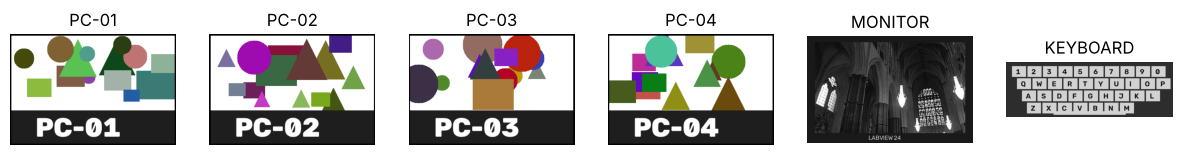

In [2]:
def make_tag(name, seed):
    r = np.random.default_rng(seed)
    tag = np.full((240, 360, 3), 255, np.uint8)
    for i in range(14):
        color = tuple(int(c) for c in r.integers(0, 200, 3))
        kind = r.integers(0, 3)
        x, y = int(r.integers(20, 340)), int(r.integers(20, 150))
        s = int(r.integers(15, 45))
        if kind == 0:
            cv2.circle(tag, (x, y), s, color, -1)
        elif kind == 1:
            cv2.rectangle(tag, (x - s, y - s), (x + s, y + s // 2), color, -1)
        else:
            cv2.fillPoly(tag, [np.array([[x, y - s], [x + s, y + s], [x - s, y + s]])], color)
    cv2.rectangle(tag, (0, 165), (360, 240), (30, 30, 30), -1)
    cv2.putText(tag, name, (55, 222), cv2.FONT_HERSHEY_DUPLEX, 2.0, (255, 255, 255), 3)
    cv2.rectangle(tag, (0, 0), (359, 239), (0, 0, 0), 4)
    return tag

def make_keyboard():
    kb = np.full((200, 600, 3), 45, np.uint8)
    rows = ["1234567890", "QWERTYUIOP", "ASDFGHJKL", "ZXCVBNM"]
    for r, row in enumerate(rows):
        for k, ch in enumerate(row):
            x = 20 + r * 18 + k * 56
            y = 15 + r * 44
            cv2.rectangle(kb, (x, y), (x + 50, y + 38), (210, 210, 210), -1)
            cv2.putText(kb, ch, (x + 14, y + 29), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (20, 20, 20), 2)
    cv2.rectangle(kb, (170, 178), (430, 190), (210, 210, 210), -1)
    return kb

def make_monitor():
    wall = cv2.imread("images/a1.png")   # using a real photo as wallpaper
    wall = cv2.resize(wall[100:500, :], (380, 230))
    mon = np.full((270, 420, 3), 25, np.uint8)
    mon[15:245, 20:400] = wall
    cv2.putText(mon, "LABVIEW 24", (155, 262), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
    return mon

db = {}
for i in range(1, 5):
    db["PC-0" + str(i)] = make_tag("PC-0" + str(i), 100 + i)
db["MONITOR"] = make_monitor()
db["KEYBOARD"] = make_keyboard()

plt.figure(figsize=(15, 4))
i = 1
for name in db:
    cv2.imwrite("images/asset_db/" + name + ".png", db[name])
    plt.subplot(1, 6, i); plt.imshow(cv2.cvtColor(db[name], cv2.COLOR_BGR2RGB)); plt.title(name); plt.axis("off")
    i += 1
plt.show()

### making the lab image

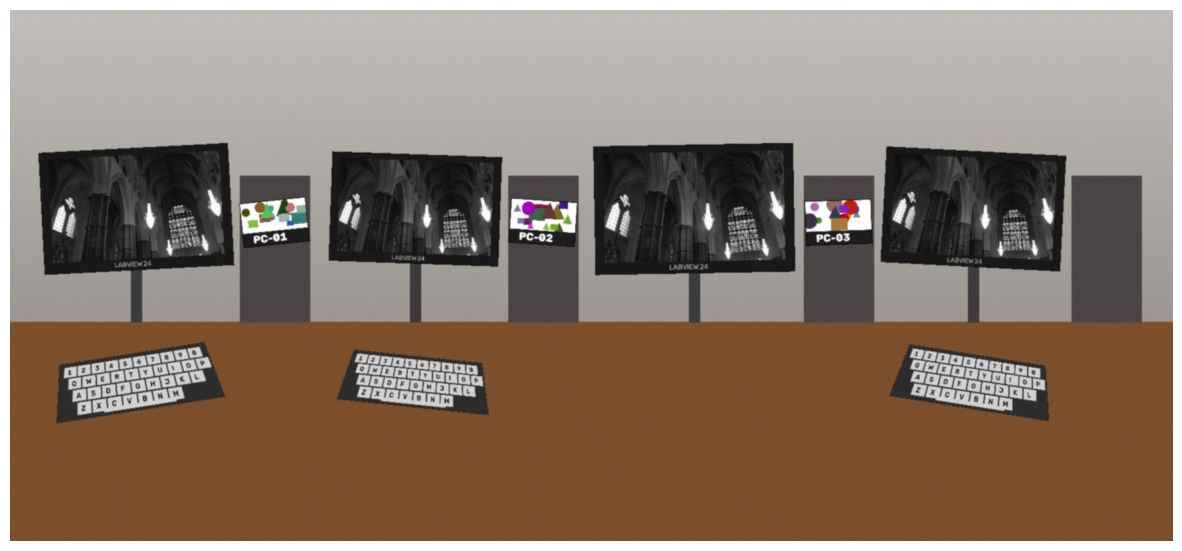

In [3]:
H, W = 800, 1750
scene = np.zeros((H, W, 3), np.uint8)
for y in range(H):
    scene[y, :] = (185 - y // 12, 190 - y // 12, 195 - y // 12)
cv2.rectangle(scene, (0, 470), (W, H), (45, 80, 125), -1)

# put a picture on 4 corner points (so it looks rotated / tilted)
def paste(src, pts):
    h, w = src.shape[:2]
    M = cv2.getPerspectiveTransform(np.float32([[0, 0], [w, 0], [w, h], [0, h]]), np.float32(pts))
    warped = cv2.warpPerspective(src, M, (W, H))
    mask = cv2.warpPerspective(np.full((h, w), 255, np.uint8), M, (W, H))
    scene[mask > 0] = warped[mask > 0]

def corners(cx, cy, w, h, angle, tilt=0):
    pts = np.array([[-w/2 + tilt, -h/2], [w/2 - tilt, -h/2], [w/2, h/2], [-w/2, h/2]])
    a = np.radians(angle)
    R = np.array([[np.cos(a), -np.sin(a)], [np.sin(a), np.cos(a)]])
    return pts @ R.T + [cx, cy]

# (tag, x, scale, angle, keyboard?)
pcs = [("PC-01", 190, 0.95, -3, True),
       ("PC-02", 610, 0.85, 2, True),
       ("PC-03", 1030, 1.00, -1, False),
       (None, 1450, 0.90, 3, True)]

for tag, cx, s, ang, kb in pcs:
    cv2.rectangle(scene, (cx - 8, 380), (cx + 8, 470), (60, 60, 60), -1)
    paste(db["MONITOR"], corners(cx, 300, 300 * s, 193 * s, ang))
    tx = cx + int(165 * s)
    cv2.rectangle(scene, (tx, 250), (tx + 105, 470), (70, 70, 75), -1)   # pc tower
    if tag:
        paste(db[tag], corners(tx + 52, 320, 100, 67, ang * 2))
    if kb:
        paste(db["KEYBOARD"], corners(cx, 560, 270 * s, 90 * s, ang * 3, 18))

scene = cv2.GaussianBlur(scene, (3, 3), 0)
scene = np.clip(scene + np.random.default_rng(3).normal(0, 3, scene.shape), 0, 255).astype(np.uint8)
cv2.imwrite("images/lab_scene_assets.png", scene)
plt.figure(figsize=(15, 8)); plt.imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()

### SIFT keypoints

scene keypoints: 3735
PC-01 114
PC-02 130
PC-03 116
PC-04 135
MONITOR 641
KEYBOARD 600


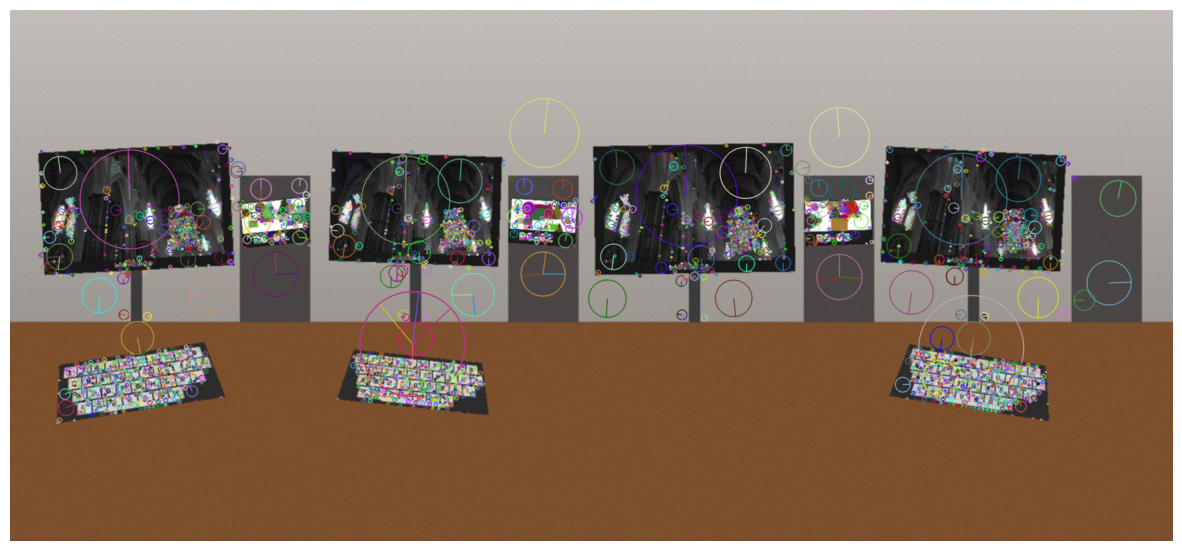

In [4]:
sift = cv2.SIFT_create()
gray = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)
kp_s, des_s = sift.detectAndCompute(gray, None)
print("scene keypoints:", len(kp_s))

feats = {}
for name in db:
    kp, des = sift.detectAndCompute(cv2.cvtColor(db[name], cv2.COLOR_BGR2GRAY), None)
    feats[name] = (kp, des)
    print(name, len(kp))

kp_img = cv2.drawKeypoints(scene, kp_s, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize=(15, 8)); plt.imshow(cv2.cvtColor(kp_img, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()

### matching
ratio test (0.75) + RANSAC homography. there are many monitors and keyboards so after finding one I remove those keypoints and search again

In [5]:
bf = cv2.BFMatcher(cv2.NORM_L2)

def find(name, max_count):
    kp_r, des_r = feats[name]
    h, w = db[name].shape[:2]
    alive = np.ones(len(kp_s), bool)
    results = []
    for t in range(max_count):
        idx = np.where(alive)[0]
        matches = bf.knnMatch(des_r, des_s[idx], k=2)
        good = []
        for m in matches:
            if len(m) == 2 and m[0].distance < 0.75 * m[1].distance:
                good.append(m[0])
        if len(good) < 12:
            break
        src = np.float32([kp_r[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst = np.float32([kp_s[idx[m.trainIdx]].pt for m in good]).reshape(-1, 1, 2)
        M, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
        if M is None or mask.sum() < 12:
            break
        box = cv2.perspectiveTransform(np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2), M).reshape(-1, 2)
        if not cv2.isContourConvex(box.astype(np.int32)) or cv2.contourArea(box) < 1500:
            break
        results.append((name, box, int(mask.sum())))
        # remove keypoints inside this box
        big = (box - box.mean(0)) * 1.1 + box.mean(0)
        for k in idx:
            if cv2.pointPolygonTest(big.astype(np.float32), kp_s[k].pt, False) >= 0:
                alive[k] = False
    return results

found = []
for name in db:
    if name.startswith("PC"):
        r = find(name, 1)
    else:
        r = find(name, 6)
    print(name, "found:", len(r), [x[2] for x in r])
    found += r

PC-01 found: 1 [25]
PC-02 found: 1 [27]
PC-03 found: 1 [19]
PC-04 found: 0 []
MONITOR found: 4 [19, 31, 41, 71]


KEYBOARD found: 3 [19, 24, 34]


### showing matches for PC-02

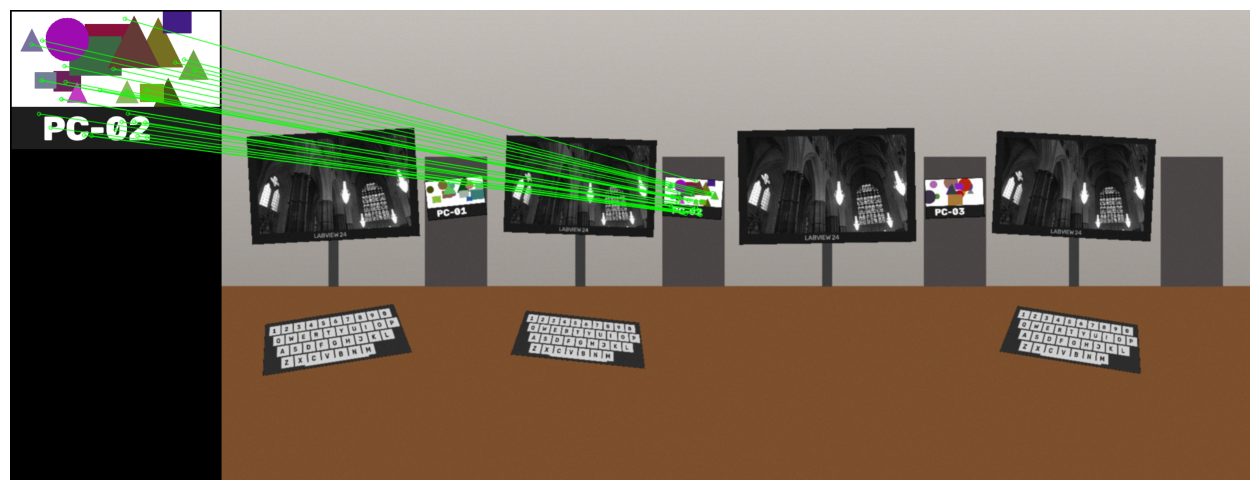

In [6]:
kp_r, des_r = feats["PC-02"]
matches = bf.knnMatch(des_r, des_s, k=2)
good = [m for m, n in matches if m.distance < 0.75 * n.distance]
src = np.float32([kp_r[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
dst = np.float32([kp_s[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
M, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
out = cv2.drawMatches(db["PC-02"], kp_r, scene, kp_s, good, None, matchColor=(0, 255, 0),
                      matchesMask=mask.ravel().tolist(), flags=2)
plt.figure(figsize=(16, 7)); plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()

### inventory
monitor and keyboard belong to the PC tower on their right side

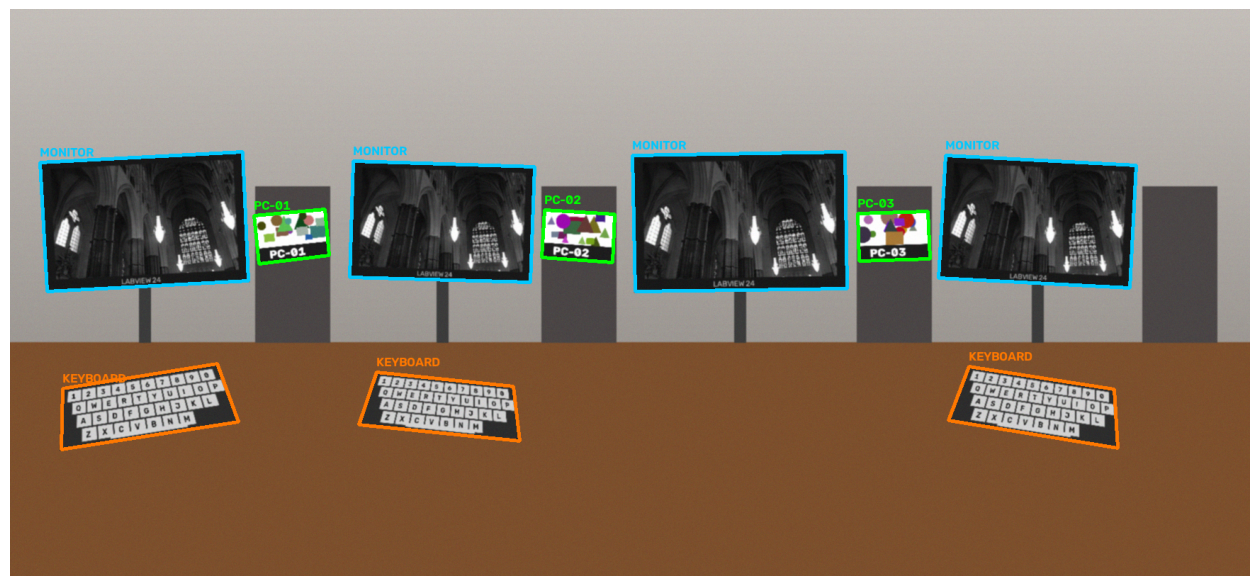

PC-01 : monitor = 1  keyboard = 1  -> ok
PC-02 : monitor = 1  keyboard = 1  -> ok
PC-03 : monitor = 1  keyboard = 0  -> keyboard missing
PC-04 : not found in lab
items with no pc tag: ['MONITOR', 'KEYBOARD']


In [7]:
result = scene.copy()
tags = [f for f in found if f[0].startswith("PC")]
inventory = {}
for t in tags:
    inventory[t[0]] = {"MONITOR": 0, "KEYBOARD": 0}
no_owner = []

for name, box, n in found:
    if name.startswith("PC"):
        color = (0, 255, 0)
    elif name == "MONITOR":
        color = (255, 200, 0)
    else:
        color = (0, 120, 255)
    cv2.polylines(result, [box.astype(np.int32)], True, color, 3)
    cv2.putText(result, name, (int(box[0][0]), int(box[0][1]) - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    if not name.startswith("PC"):
        cx = box[:, 0].mean()
        owner = None
        best = 300
        for tname, tbox, tn in tags:
            d = tbox[:, 0].mean() - cx
            if 0 < d < best:
                best = d
                owner = tname
        if owner:
            inventory[owner][name] += 1
        else:
            no_owner.append(name)

plt.figure(figsize=(16, 9)); plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()
cv2.imwrite("outputs/task2_assets.png", result)

for pc in ["PC-01", "PC-02", "PC-03", "PC-04"]:
    if pc not in inventory:
        print(pc, ": not found in lab")
    else:
        m = inventory[pc]["MONITOR"]
        k = inventory[pc]["KEYBOARD"]
        msg = "ok"
        if m == 0: msg = "monitor missing"
        if k == 0: msg = "keyboard missing"
        print(pc, ": monitor =", m, " keyboard =", k, " ->", msg)
print("items with no pc tag:", no_owner)